# Tarea 1 - Modulo 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, lognorm, iqr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
np.random.seed(42)

# ── Detección de outliers ──────────────────────────────────────

def detectar_outliers_iqr(serie, factor=1.5):
    """Detección por Rango Intercuartílico."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - factor*IQR, Q3 + factor*IQR
    return serie < li, serie > ls, li, ls

def detectar_outliers_zscore(serie, umbral=3):
    """Detección por Z-Score clásico."""
    return np.abs(stats.zscore(serie)) > umbral

def detectar_outliers_zscore_mod(serie, umbral=3.5):
    """Detección por Z-Score Modificado (robusto a outliers)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    if MAD == 0:
        return pd.Series([False]*len(serie), index=serie.index)
    return 0.6745 * np.abs(serie - mediana) / MAD > umbral

def resumen_outliers(serie, nombre='Variable'):
    """Reporte comparativo de todos los métodos de detección."""
    _, out_iqr, li, ls = detectar_outliers_iqr(serie)
    out_z  = detectar_outliers_zscore(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    p99    = serie.quantile(0.99)
    print(f"\n{'='*55}")
    print(f"  📊 Resumen de Outliers: {nombre}")
    print(f"{'='*55}")
    print(f"  N total          : {len(serie):,}")
    print(f"  Media            : {serie.mean():,.2f}")
    print(f"  Mediana          : {serie.median():,.2f}")
    print(f"  Desv. Estándar   : {serie.std():,.2f}")
    print(f"  Mín / Máx        : {serie.min():,.2f} / {serie.max():,.2f}")
    print(f"  Percentil 99     : {p99:,.2f}")
    print(f"  Asimetría (skew) : {serie.skew():.3f}")
    print(f"  Curtosis         : {serie.kurtosis():.3f}")
    print(f"\n  --- Outliers detectados ---")
    print(f"  IQR (×1.5)       : {out_iqr.sum():,} ({out_iqr.mean()*100:.1f}%)  [>{ls:,.0f}]")
    print(f"  Z-Score (|z|>3)  : {out_z.sum():,} ({out_z.mean()*100:.1f}%)")
    print(f"  Z-Score Mod.     : {out_zm.sum():,} ({out_zm.mean()*100:.1f}%)")
    print(f"  Capping p99      : {(serie>p99).sum():,} ({(serie>p99).mean()*100:.1f}%)")
    print(f"{'='*55}")
    return {'iqr':out_iqr,'zscore':out_z,'zscore_mod':out_zm,
            'p99':serie>p99,'lim_sup_iqr':ls,'p99_val':p99}

def winsorizar(serie, p_inf=0.0, p_sup=0.99):
    """Winsorización entre percentiles."""
    return serie.clip(lower=serie.quantile(p_inf), upper=serie.quantile(p_sup))

# ── Transformaciones estabilizadoras ──────────────────────────

def t_sqrt(x):
    """Raíz cuadrada. x >= 0."""
    return np.sqrt(np.maximum(x, 0))

def t_arcsin_sqrt(p):
    """Arcoseno de raíz cuadrada. p en [0,1]."""
    return np.arcsin(np.sqrt(np.clip(p, 0, 1)))

def t_arcsinh(x, escala=1.0):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

print('✅ Setup completo — funciones de detección y transformación listas')

✅ Setup completo — funciones de detección y transformación listas


---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.

In [3]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000



  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


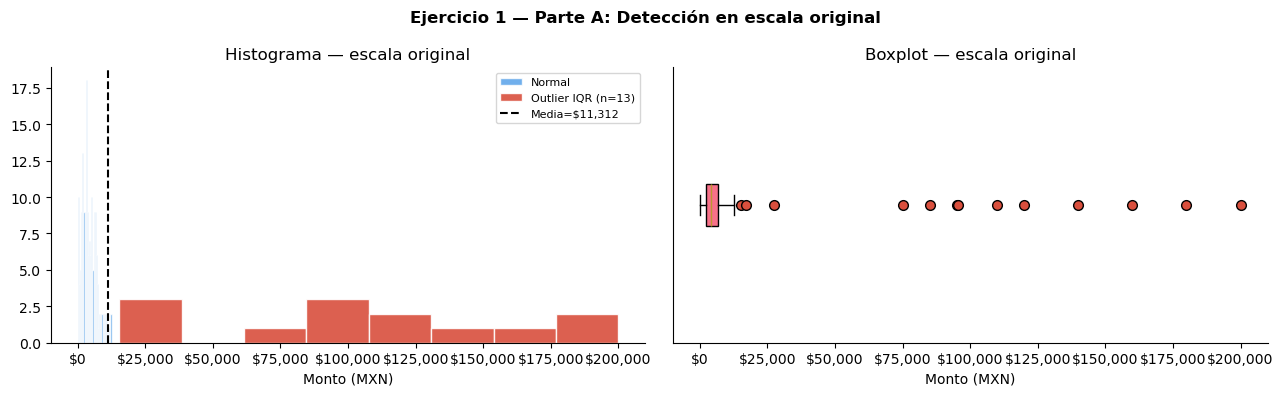

In [4]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()


In [5]:
# Paso 1: Calcular transformaciones
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh

# Normalización para arcsin(√p): dividir por el máximo → p ∈ [0,1]
p_norm = siniestros_ej1 / siniestros_ej1.max()

transf = pd.DataFrame({
    'original'     : siniestros_ej1,
    'sqrt'         : t_sqrt(siniestros_ej1),
    'arcsinh'      : t_arcsinh(siniestros_ej1, escala=ref_ej1),
    'log'          : np.log1p(siniestros_ej1)        
})

# Paso 2: Asimetría por escala
print('Asimetría (skewness) por transformación:')
print('-'*42)
labels = {
    'original'   : 'Sin transformar',
    'sqrt'       : '√x',
    'arcsinh'    : 'arcsinh(x/mediana)',
    'log'        : 'log(x+1) '
}
for col, label in labels.items():
    sk = transf[col].skew()
    kurt = transf[col].kurtosis()
    print(f'  {label:<30}: skew={sk:+.3f}  kurt={kurt:+.3f}')


print('\n-La transformación sqrt reduce moderadamente la asimetría')
print('-log(x+1) nos dice que esta transformacion comprimió mucho la cola derecha')
print('-arcsinh(x/mediana) logra el mejor balance entre reducción de asimetria y preservación de estructura de datos' \
'\npor lo que es la mejor transformacion')

Asimetría (skewness) por transformación:
------------------------------------------
  Sin transformar               : skew=+4.522  kurt=+20.903
  √x                            : skew=+3.300  kurt=+11.734
  arcsinh(x/mediana)            : skew=+2.321  kurt=+6.158
  log(x+1)                      : skew=-2.411  kurt=+7.546

-La transformación sqrt reduce moderadamente la asimetría
-log(x+1) nos dice que esta transformacion comprimió mucho la cola derecha
-arcsinh(x/mediana) logra el mejor balance entre reducción de asimetria y preservación de estructura de datos
por lo que es la mejor transformacion


IndexError: list index out of range

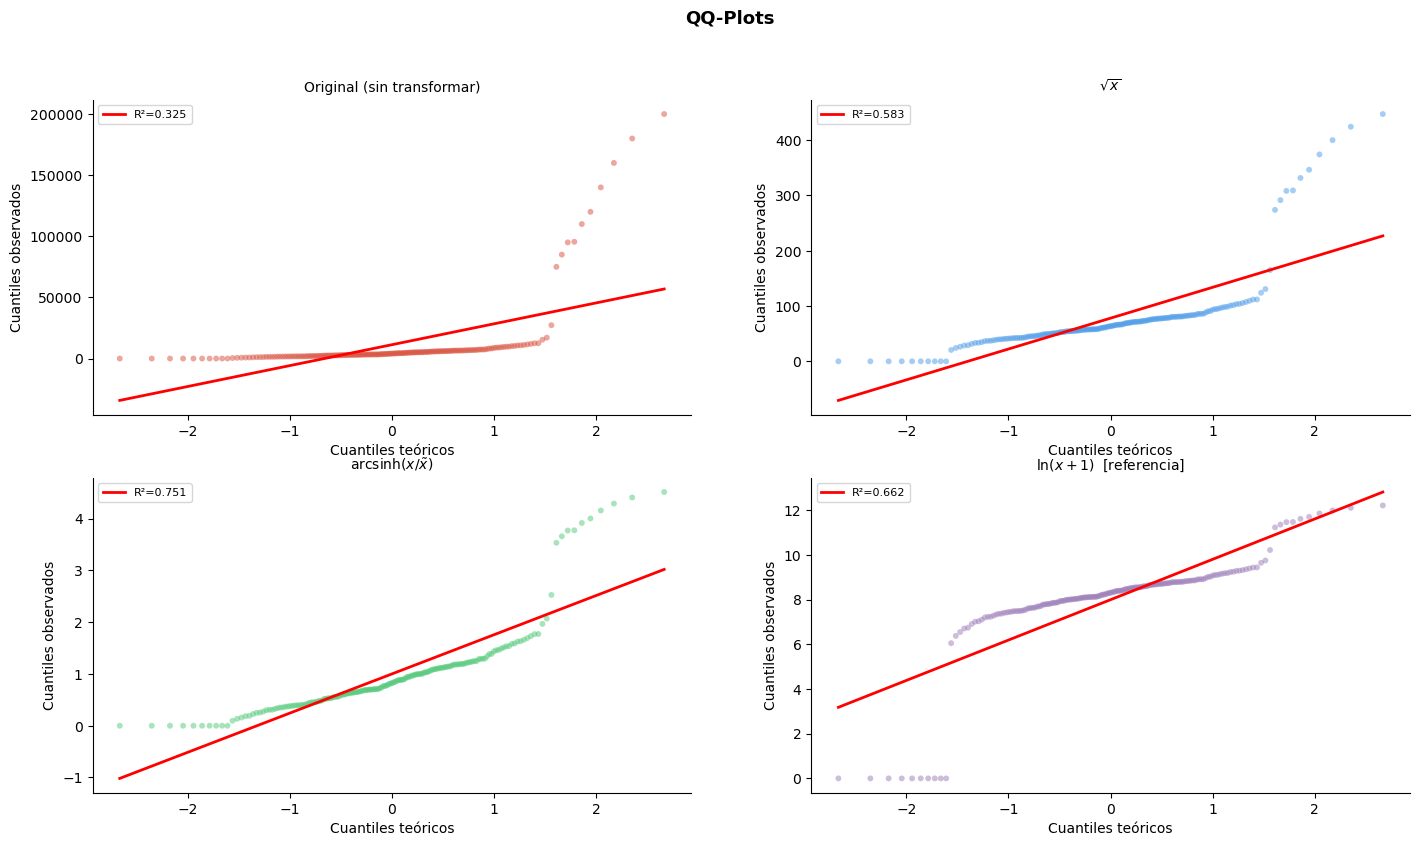

In [6]:
# Paso 3: QQ-Plots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
fig.suptitle('QQ-Plots', fontsize=13, fontweight='bold')

configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('sqrt',        '$\\sqrt{x}$',                 '#4C9BE8'),
    ('arcsinh',     '$\\text{arcsinh}(x/\\tilde{x})$', '#50C878'),
    ('log',         '$\\ln(x+1)$  [referencia]',     '#9B7CB8'),
]

axes_flat = list(axes.flat)
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)


ax = list(axes_flat)[4] # a pesar de que marca error, de eliminarse la grafica se distorsiona
ax2 = ax.twinx()
ax.hist(transf['original'], bins=50, alpha=0.5, color='#D94F3D', density=True,
        label='Original')
ax2.hist(transf['arcsinh'], bins=50, alpha=0.5, color='#50C878', density=True,
         label='arcsinh')
ax.set_title('Original vs arcsinh (densidad)', fontsize=10)
ax.set_xlabel('Valor')
ax.set_ylabel('Densidad (original)', color='#D94F3D')
ax2.set_ylabel('Densidad (arcsinh)', color='#50C878')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# Paso 4: Detección outliers IQR en cada escala
resultados_deteccion = {}
for col, label in [('original','Original'), ('sqrt','√x'),
                    ('arcsinh', 'arcsinh'), ('log','log(x+1)')]:
    serie = transf[col]
    _, out_iqr, _, lim_s = detectar_outliers_iqr(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    resultados_deteccion[label] = {
        'IQR_n': out_iqr.sum(), 'IQR_pct': out_iqr.mean()*100,
        'ZMod_n': out_zm.sum(), 'ZMod_pct': out_zm.mean()*100
    }

df_det = pd.DataFrame(resultados_deteccion).T
print('Comparación de detección según escala de análisis:')
print('='*60)
print(f'{"Escala":<12} {"IQR (n)":>8} {"IQR (%)":>9} {"Z-Mod (n)":>10} {"Z-Mod (%)":>10}')
print('-'*60)
for idx, row in df_det.iterrows():
    print(f'{idx:<12} {row.IQR_n:>8.0f} {row.IQR_pct:>8.1f}% {row.ZMod_n:>10.0f} {row.ZMod_pct:>9.1f}%')



Comparación de detección según escala de análisis:
Escala        IQR (n)   IQR (%)  Z-Mod (n)  Z-Mod (%)
------------------------------------------------------------
Original           13      7.2%         13       7.2%
√x                 12      6.7%         11       6.1%
arcsinh            11      6.1%         10       5.6%
log(x+1)           10      5.6%         20      11.1%


In [8]:
# calculamos las primas
_, out_iqr, _, _ = detectar_outliers_iqr(siniestros_ej1)
sin_no_out = siniestros_ej1[~out_iqr]

prima_full = siniestros_ej1.mean()
prima_no_out = sin_no_out.mean()

print(f"Prima con outliers    : {prima_full:,.2f}")
print(f"Prima sin outliers    : {prima_no_out:,.2f}")

print('\nLa prima pura disminuye significativamente al eliminar outliers, haciendo ver que los ' \
'\nsiniestros extremos tienen un impacto en el valor esperado.')

Prima con outliers    : 11,311.57
Prima sin outliers    : 4,286.80

La prima pura disminuye significativamente al eliminar outliers, haciendo ver que los 
siniestros extremos tienen un impacto en el valor esperado.


---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


In [9]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0


In [13]:
# 1. Detectar sucursales con frecuencia atípica
x = df_vida_grupo['Dias_Incapacidad']

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'\nLimites: [{LI:.2f}, {LS:.2f}]')
print()

df_vida_grupo['Outlier_IQR'] = (
    (x < LI) | (x > LS)
)

print(df_vida_grupo.groupby('Sucursal')['Outlier_IQR']
      .sum()
      .sort_values(ascending=False))

print('\nNotemos que la zona Centro es la sucursal más atípica')

Q1=3.00, Q3=8.00, IQR=5.00

Limites: [-4.50, 15.50]

Sucursal
Centro    5
Este      0
Norte     0
Oeste     0
Sur       0
Name: Outlier_IQR, dtype: int64

Notemos que la zona Centro es la sucursal más atípica


In [14]:
# 2. Tasa de siniestralidad por sucursal
tasas = (
    df_vida_grupo
    .groupby('Sucursal')
    .agg(
        Empleados=('Empleado_ID', 'count'),
        Total_Dias=('Dias_Incapacidad', 'sum'),
        Tasa_Promedio=('Dias_Incapacidad', 'mean'),
        Desv=('Dias_Incapacidad', 'std')
    )
    .sort_values('Tasa_Promedio', ascending=False)
)

print(tasas.round(2))
print('\nLa sucursal Centro presenta una frecuencia promedio de incapacidad superior al resto')




          Empleados  Total_Dias  Tasa_Promedio  Desv
Sucursal                                            
Centro           32         397          12.41  3.56
Este             19          95           5.00  2.13
Sur              25         110           4.40  2.36
Oeste            25          88           3.52  2.08
Norte            19          56           2.95  1.65

La sucursal Centro presenta una frecuencia promedio de incapacidad superior al resto


<Figure size 1000x600 with 0 Axes>

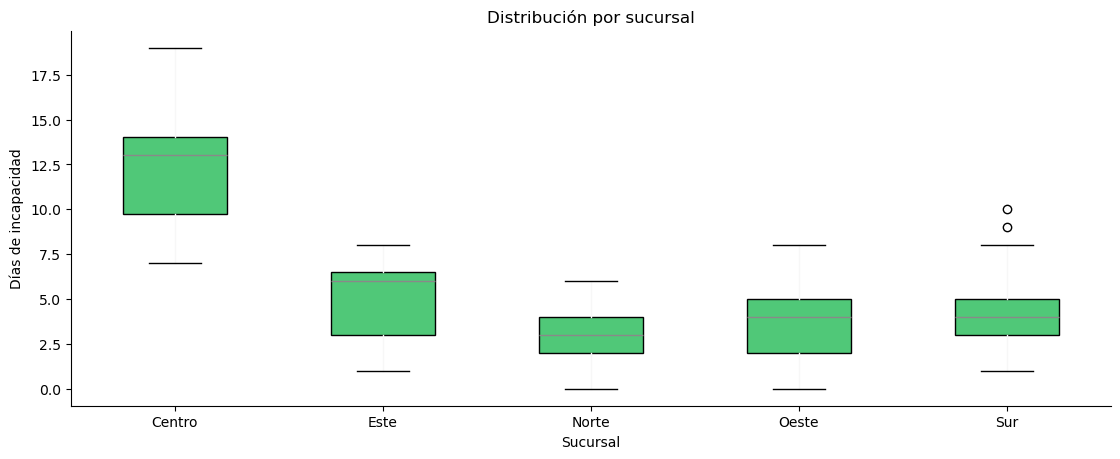

In [15]:
# 3. Visualización
plt.figure(figsize=(10,6))

df_vida_grupo.boxplot(
    column='Dias_Incapacidad',
    by='Sucursal',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor='#50C878')
)

plt.title('Distribución por sucursal')
plt.suptitle('')
plt.xlabel('Sucursal')
plt.ylabel('Días de incapacidad')

plt.show()

In [17]:
# Aplicamos transformacion sqrt(x)
df_vida_grupo['sqrt_dias'] = np.sqrt(df_vida_grupo['Dias_Incapacidad'])

y = df_vida_grupo['sqrt_dias']

Q1_y = y.quantile(0.25)
Q3_y = y.quantile(0.75)
IQR_y = Q3_y - Q1_y

LI_y = Q1_y - 1.5 * IQR_y
LS_y = Q3_y + 1.5 * IQR_y

df_vida_grupo['Outlier_sqrt'] = (
    (y < LI_y) | (y > LS_y)
)

print(df_vida_grupo.groupby('Sucursal')['Outlier_sqrt']
      .sum()
      .sort_values(ascending=False))
print('\nNotemos que el numero de outliers disminuyeron ')

Sucursal
Norte     2
Oeste     1
Centro    0
Este      0
Sur       0
Name: Outlier_sqrt, dtype: int64

Notemos que el numero de outliers disminuyeron 


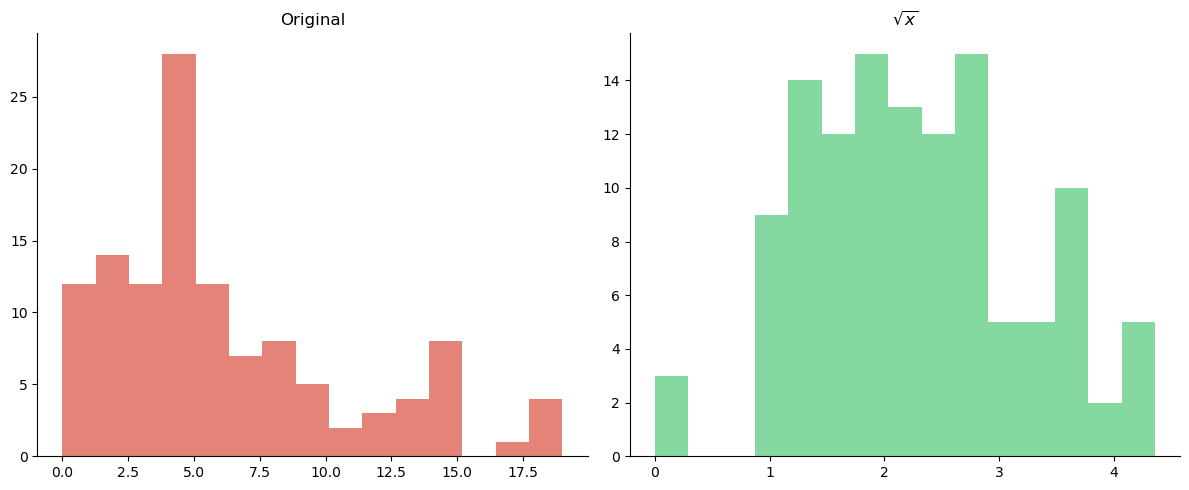


Con la transformación se observa algo mas "normal" 


In [18]:
# Grafiquemos
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original
axes[0].hist(
    df_vida_grupo['Dias_Incapacidad'],
    bins=15,
    color='#D94F3D',
    alpha=0.7
)

axes[0].set_title('Original')

# sqrt
axes[1].hist(
    np.sqrt(df_vida_grupo['Dias_Incapacidad']),
    bins=15,
    color='#50C878',
    alpha=0.7
)

axes[1].set_title(r'$\sqrt{x}$')

plt.tight_layout()
plt.show()

print('\nCon la transformación se observa algo mas "normal" ')

In [20]:
# Calculamos tasa relativa por sucursal
resumen = (
    df_vida_grupo
    .groupby('Sucursal')['Dias_Incapacidad']
    .agg(['mean', 'count'])
)

max_mean = resumen['mean'].max()

resumen['p_j'] = resumen['mean'] / max_mean

print(resumen)
print('\nAl ser Centro la zona mas riesgosa obtenemos que la tasa relativa es 1')
print('Notemos que la segunda sucursal más grande, Este, tiene menos de la mitad de la frecuencia de Centro.')

               mean  count       p_j
Sucursal                            
Centro    12.406250     32  1.000000
Este       5.000000     19  0.403023
Norte      2.947368     19  0.237571
Oeste      3.520000     25  0.283728
Sur        4.400000     25  0.354660

Al ser Centro la zona mas riesgosa obtenemos que la tasa relativa es 1
Notemos que la segunda sucursal más grande, Este, tiene menos de la mitad de la frecuencia de Centro.


In [22]:
# Calculamos los intercalos de confianza al 95%
resumen['theta'] = np.arcsin(np.sqrt(resumen['p_j']))

resumen['SE'] = 1 / (2 * np.sqrt(resumen['count']))

z = 1.96

resumen['LI(95%)'] = resumen['theta'] - z * resumen['SE']
resumen['LS(95%)'] = resumen['theta'] + z * resumen['SE']

print(resumen[['mean', 'p_j', 'theta', 'LI(95%)', 'LS(95%)']])
print('\nAl aplicar la transformación angular, notemos que lOS IC respecto al centro tienen una separacion considerable')
print('La sucursal Centro, incluso despues de las tranformaciones, es estadisticamente diferente al resto')

               mean       p_j     theta   LI(95%)   LS(95%)
Sucursal                                                   
Centro    12.406250  1.000000  1.570796  1.397555  1.744037
Este       5.000000  0.403023  0.687802  0.462975  0.912630
Norte      2.947368  0.237571  0.509124  0.284297  0.733952
Oeste      3.520000  0.283728  0.561742  0.365742  0.757742
Sur        4.400000  0.354660  0.637929  0.441929  0.833929

Al aplicar la transformación angular, notemos que lOS IC respecto al centro tienen una separacion considerable
La sucursal Centro, incluso despues de las tranformaciones, es estadisticamente diferente al resto


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


In [24]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))

Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00


In [25]:
# 1. Outliers de frecuencia
res_freq = resumen_outliers(freq_hogar,'Frecuencia')

# 2. Outliers de severidad
res_sev= resumen_outliers(sev_hogar,'Severidad')


  📊 Resumen de Outliers: Frecuencia
  N total          : 130
  Media            : 2.01
  Mediana          : 1.00
  Desv. Estándar   : 2.29
  Mín / Máx        : 0.00 / 12.00
  Percentil 99     : 10.71
  Asimetría (skew) : 2.303
  Curtosis         : 5.860

  --- Outliers detectados ---
  IQR (×1.5)       : 18 (13.8%)  [>4]
  Z-Score (|z|>3)  : 5 (3.8%)
  Z-Score Mod.     : 9 (6.9%)
  Capping p99      : 2 (1.5%)

  📊 Resumen de Outliers: Severidad
  N total          : 130
  Media            : 41,788.53
  Mediana          : 8,424.76
  Desv. Estándar   : 116,951.19
  Mín / Máx        : 2,512.53 / 600,000.00
  Percentil 99     : 541,300.00
  Asimetría (skew) : 3.503
  Curtosis         : 11.198

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (10.0%)  [>21,496]
  Z-Score (|z|>3)  : 6 (4.6%)
  Z-Score Mod.     : 13 (10.0%)
  Capping p99      : 2 (1.5%)


In [26]:
# guardamos los valores de los outliers
_, out_freq, _, _ = detectar_outliers_iqr(
    df_hogar['Num_Siniestros']
)

_, out_sev, _, _ = detectar_outliers_iqr(
    df_hogar['Monto_Promedio_MXN']
)

df_hogar['Out_Freq'] = out_freq
df_hogar['Out_Sev'] = out_sev

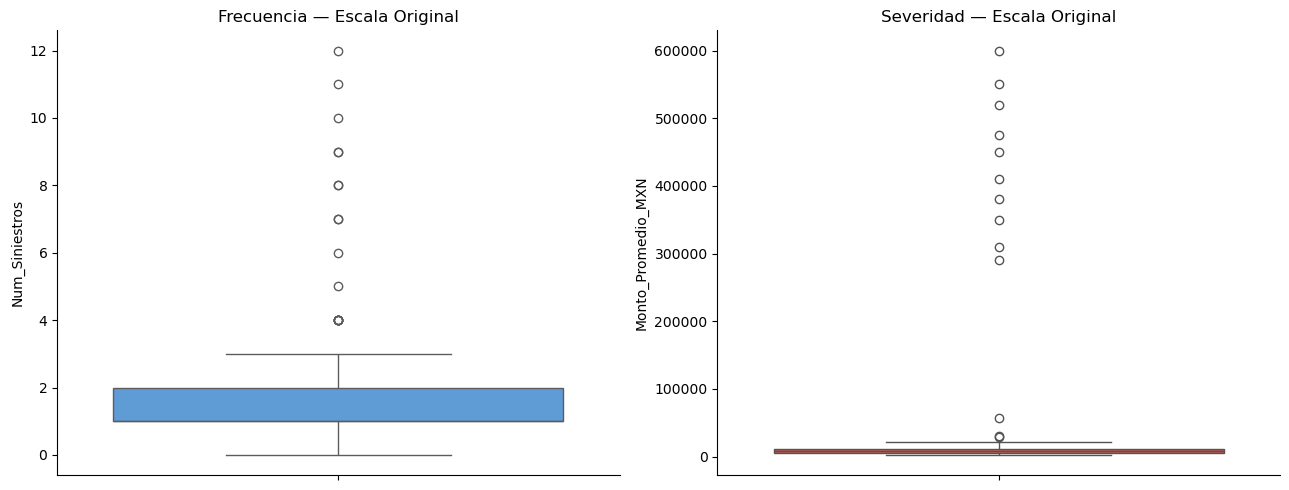


Notemos que existen montos de severidad demasiado grandes por encima del promedio


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(
    y=df_hogar['Num_Siniestros'],
    ax=axes[0],
    color='#4C9BE8'
)

axes[0].set_title('Frecuencia — Escala Original')

sns.boxplot(
    y=df_hogar['Monto_Promedio_MXN'],
    ax=axes[1],
    color='#D94F3D'
)

axes[1].set_title('Severidad — Escala Original')

plt.tight_layout()
plt.show()

print('\nNotemos que existen montos de severidad demasiado grandes por encima del promedio')

In [29]:
# 3. Prima pura en 4 escenarios
def prima_pura(df):
    return (
        df['Num_Siniestros'].mean()
        * df['Monto_Promedio_MXN'].mean()
    )

escenarios = {
    'Original':
        df_hogar,

    'Sin outliers frecuencia':
        df_hogar[~df_hogar['Out_Freq']],

    'Sin outliers severidad':
        df_hogar[~df_hogar['Out_Sev']],

    'Sin ambos':
        df_hogar[
            ~(df_hogar['Out_Freq']
              | df_hogar['Out_Sev'])
        ]
}

prima_res = []

for nombre, df_esc in escenarios.items():

    prima = prima_pura(df_esc)

    prima_res.append({
        'Escenario': nombre,
        'N': len(df_esc),
        'Prima_Pura': prima
    })

prima_df = pd.DataFrame(prima_res)

print(prima_df.round(2))
print()
print('Notemos que al eliminar extremos se subestimaria considerablemente la prima.')
print('Al tener primas similares entre el escenario 2 y 3 nos indica que la frecuencia y severidad contribuyen conjuntamente')
print(', es decir, los casos graves son extremos de ambas variables.')


                 Escenario    N  Prima_Pura
0                 Original  130    83898.50
1  Sin outliers frecuencia  112    11532.47
2   Sin outliers severidad  117    12395.58
3                Sin ambos  109    10714.75

Notemos que al eliminar extremos se subestimaria considerablemente la prima.
Al tener primas similares entre el escenario 2 y 3 nos indica que la frecuencia y severidad contribuyen conjuntamente
, es decir, los casos graves son extremos de ambas variables.


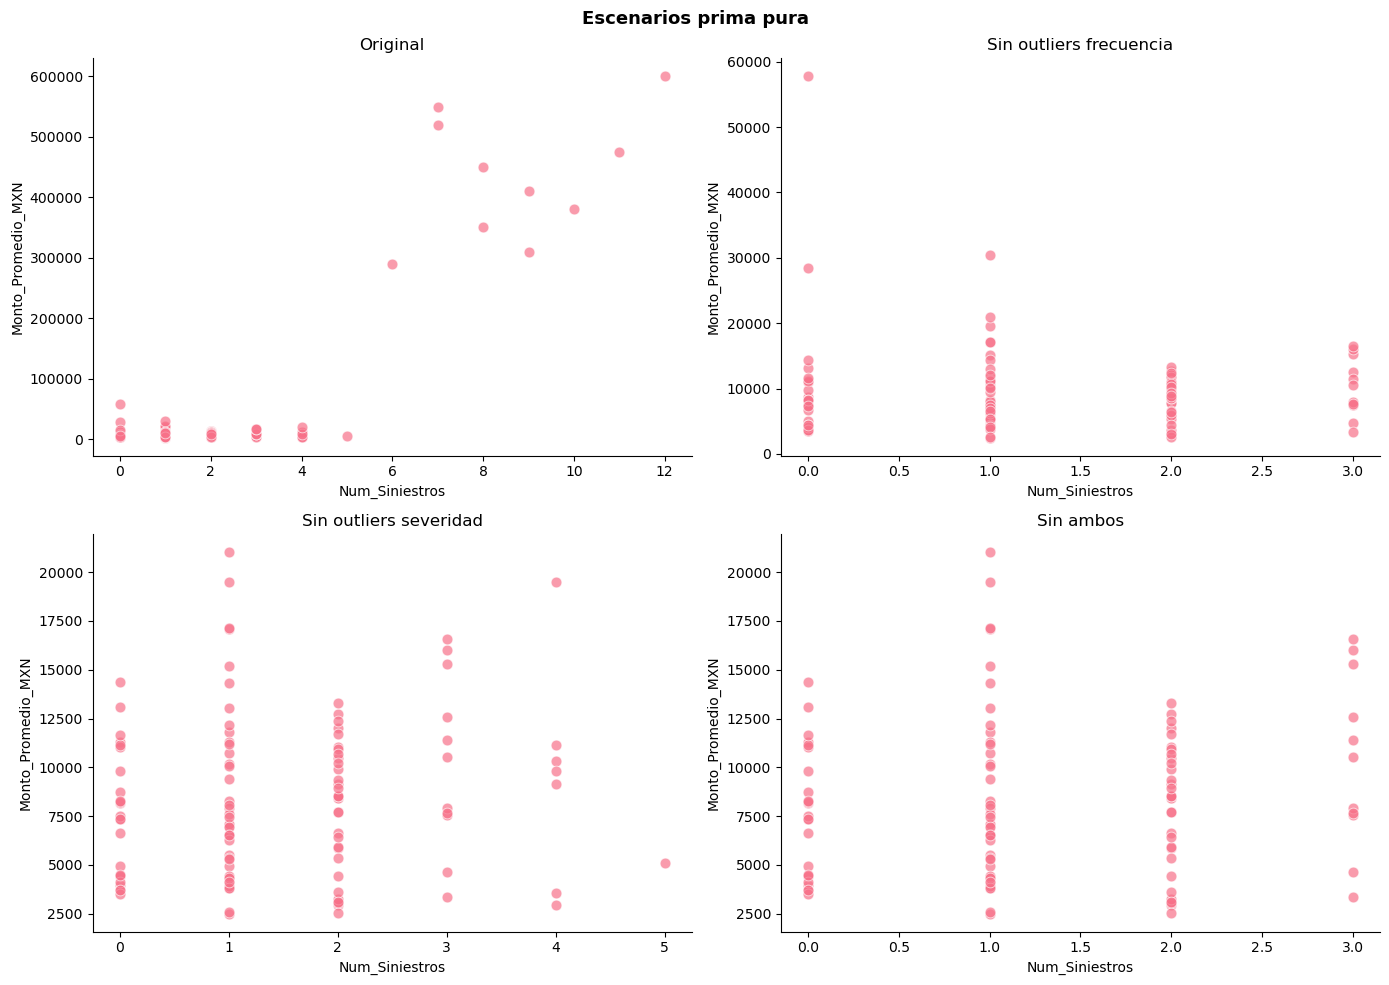

En las grafica con la informacion original confirmamos que los valores extremos provienen de ambas variables (frecuencia y severidad)
Notemos que la severidad extrema sigue siendo una fuente importante de riesgo incluso cuando se eliminan pólizas con 
frecuencia anormalmente alta.


In [ ]:
# Veamoslo graficamente
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Escenarios prima pura', fontsize=13, fontweight='bold')

axes = axes.flatten()

for ax, (nombre, df_esc) in zip(axes, escenarios.items()):

    sns.scatterplot(
        data=df_esc,
        x='Num_Siniestros',
        y='Monto_Promedio_MXN',
        ax=ax,
        alpha=0.7,
        s=60
    )

    ax.set_title(nombre)

plt.tight_layout()
plt.show()

print('En las grafica con la informacion original confirmamos que los valores extremos provienen de ambas variables (frecuencia y severidad)')
print('Notemos que la severidad extrema sigue siendo una fuente importante de riesgo incluso cuando se eliminan pólizas con ' \
'\nfrecuencia anormalmente alta.')


In [31]:
# Aplicamos transformacion a la frecuencia
df_hogar['Freq_sqrt'] = t_sqrt(
    df_hogar['Num_Siniestros']
)

# Aplicamos transformacion a la severidad
mediana_sev = df_hogar['Monto_Promedio_MXN'].median()

df_hogar['Sev_arcsinh'] = t_arcsinh(
    df_hogar['Monto_Promedio_MXN'],
    escala=mediana_sev
)

# Comparamos
comparacion = pd.DataFrame({

    'Variable': [
        'Freq original',
        'Freq sqrt',
        'Sev original',
        'Sev arcsinh'
    ],

    'Skewness': [
        df_hogar['Num_Siniestros'].skew(),
        df_hogar['Freq_sqrt'].skew(),
        df_hogar['Monto_Promedio_MXN'].skew(),
        df_hogar['Sev_arcsinh'].skew()
    ],

    'Kurtosis': [
        df_hogar['Num_Siniestros'].kurtosis(),
        df_hogar['Freq_sqrt'].kurtosis(),
        df_hogar['Monto_Promedio_MXN'].kurtosis(),
        df_hogar['Sev_arcsinh'].kurtosis()
    ]
})

print(comparacion.round(3))

print()
print('Notemos que para la frecuencia, la transformacion fue favorable al reducir significativamente la curtosis y la asimetria')
print('Por otro lado, la severidad presenta colas pesadas aun despues de la trnasformacion')

        Variable  Skewness  Kurtosis
0  Freq original     2.303     5.860
1      Freq sqrt     0.375     0.458
2   Sev original     3.503    11.198
3    Sev arcsinh     2.619     6.097

Notemos que para la frecuencia, la transformacion fue favorable al reducir significativamente la curtosis y la asimetria
Por otro lado, la severidad presenta colas pesadas aun despues de la trnasformacion


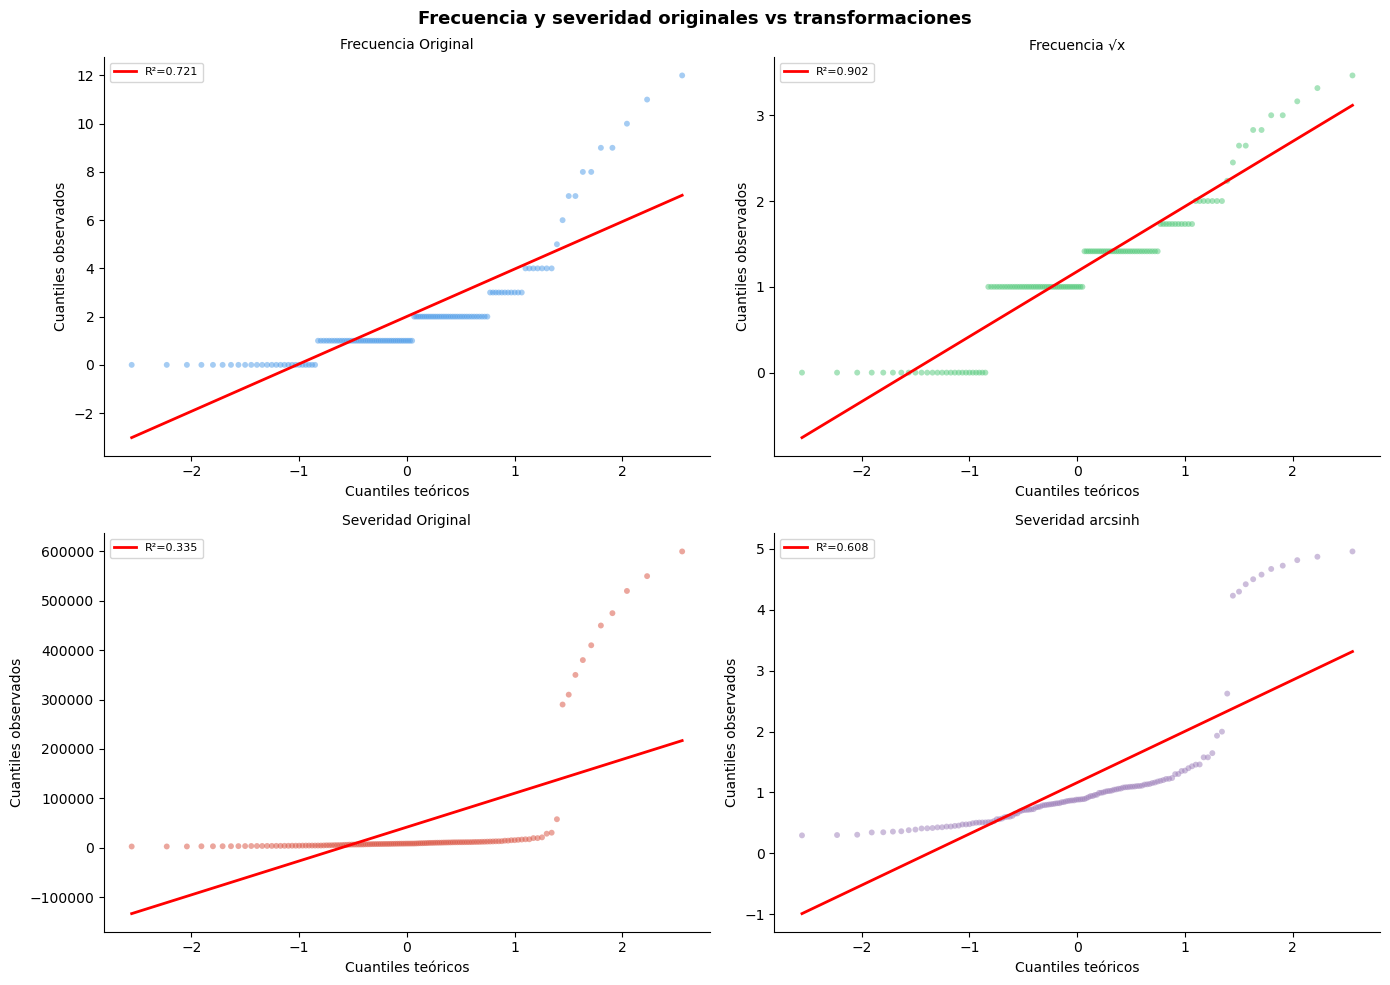

In [32]:
# Veamos como se ven los datos con las transformaciones
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Frecuencia y severidad originales vs transformaciones', fontsize=13, fontweight='bold')

axes = axes.flatten()

qqplot_ax(
    axes[0],
    df_hogar['Num_Siniestros'],
    'Frecuencia Original',
    '#4C9BE8'
)

qqplot_ax(
    axes[1],
    df_hogar['Freq_sqrt'],
    'Frecuencia √x',
    '#50C878'
)

qqplot_ax(
    axes[2],
    df_hogar['Monto_Promedio_MXN'],
    'Severidad Original',
    '#D94F3D'
)

qqplot_ax(
    axes[3],
    df_hogar['Sev_arcsinh'],
    'Severidad arcsinh',
    '#9B7CB8'
)

plt.tight_layout()
plt.show()

In [34]:
# 4. Pólizas con doble outlier
df_hogar['Doble_Out_Original'] = (
    df_hogar['Out_Freq']
    &
    df_hogar['Out_Sev']
)

print(f"Doble outlier original: {df_hogar['Doble_Out_Original'].sum()}")

_, out_freq_t, _, _ = detectar_outliers_iqr(
    df_hogar['Freq_sqrt']
)

_, out_sev_t, _, _ = detectar_outliers_iqr(
    df_hogar['Sev_arcsinh']
)

df_hogar['Doble_Out_Transformado'] = (
    out_freq_t
    &
    out_sev_t
)

print(f"Doble outlier transformado: {df_hogar['Doble_Out_Transformado'].sum()}")
print('\nTenemos el mismo numero de polizas, esto debido a que las transformaciones son monotonas y preservan el orden relativo de las observaciones')


Doble outlier original: 10
Doble outlier transformado: 10

Tenemos el mismo numero de polizas, esto debido a que las transformaciones son monotonas y preservan el orden relativo de las observaciones


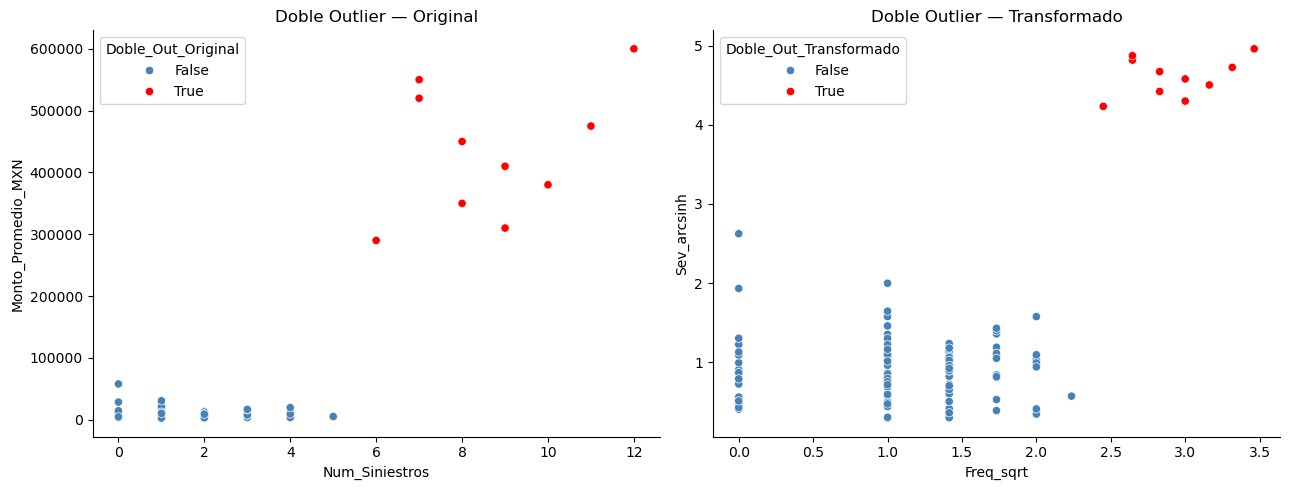

Graficamente se ve lo descrito anteriormente
Las escalas cambian pero los valores extremos siguen preservandose a pesar de las transformaciones


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Original
sns.scatterplot(
    data=df_hogar,
    x='Num_Siniestros',
    y='Monto_Promedio_MXN',
    hue='Doble_Out_Original',
    palette={False: "steelblue", True: "red"},
    ax=axes[0]
)

axes[0].set_title('Doble Outlier — Original')

# Transformado
sns.scatterplot(
    data=df_hogar,
    x='Freq_sqrt',
    y='Sev_arcsinh',
    hue='Doble_Out_Transformado',
    palette={False: "steelblue", True: "red"},
    ax=axes[1]
)

axes[1].set_title('Doble Outlier — Transformado')

plt.tight_layout()
plt.show()

print('Graficamente se ve lo descrito anteriormente')
print('Las escalas cambian pero los valores extremos siguen preservandose a pesar de las transformaciones')

In [36]:
media_original = (
    df_hogar['Monto_Promedio_MXN']
    .mean()
)

media_transformada = (
    np.sinh(df_hogar['Sev_arcsinh'].mean())
    * mediana_sev
)

print(f'Media original        : {media_original:,.2f}')
print(f'Inverse-arcsinh(media): {media_transformada:,.2f}')

Media original        : 41,788.53
Inverse-arcsinh(media): 12,136.40


In [37]:
print(f"La media en el espacio transformado no conserva la esperanza en escala original. Esto se evidencia en los resultados obtenidos, \
\ndonde la media original de la severidad es aproximadamente {media_original:,.2f}, mientras que la media reconstruida a partir de la transformación\
\narcsinh es {media_transformada:,.2f}, lo que implica una subestimación importante del valor esperado.")

La media en el espacio transformado no conserva la esperanza en escala original. Esto se evidencia en los resultados obtenidos, 
donde la media original de la severidad es aproximadamente 41,788.53, mientras que la media reconstruida a partir de la transformación
arcsinh es 12,136.40, lo que implica una subestimación importante del valor esperado.
